In [4]:
import tskit
import pandas as pd
import numpy as np
import pyslim
import msprime
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

from kasper_stats import kasper_run_stat, kasper_comb_stat
%config InlineBackend.figure_format = 'retina'

Some plotting functions:

In [5]:
def stairs(df, start='start', end='end', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

def add_lowess(x, y, ax=None, is_sorted=True, frac=0.005, it=0, **kwargs):
    "Add a lowess curve to the plot"
    if ax is None:
        ax = plt.gca() 
    filtered = lowess(y, x, is_sorted=is_sorted, frac=frac, it=it)
    ax.plot(filtered[:,0], filtered[:,1], **kwargs)

Amplicon positions:

In [6]:
import seaborn as sns
amplicon_intervals = [(2003, 3003), (10003003, 10004003), (20004003, 20005003)]
amplicon_average_positions = [(sum(e) // 2) for e in amplicon_intervals]

Population size and generations for run to plot:

# @Davide: The paths below define a run to analyze. You can just copy the entire notebook so you have one for each analysis and then edit the lines paths below in each one:

In [10]:
tree_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0.0000050000__r_0.0000000500__S_2_{replicate}_treestats.h5'
window_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0.0000050000__r_0.0000000500__S_2_{replicate}_windowstats.h5'

# # # E.g. for S = 20
# tree_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0.0000050000__r_0.0000000500__S_20_{replicate}_treestats.h5'
# window_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0.0000050000__r_0.0000000500__S_20_{replicate}_windowstats.h5'

# # or for the sweep
# tree_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0__r_0.0000000500__S_0.1_{replicate}_treestats.h5'
# window_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0__r_0.0000000500__S_0.1_{replicate}_windowstats.h5'

# # or the neutral run
# tree_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0__r_0.0000000500__S_0.1_{replicate}_treestats.h5'
# window_stats_path_template = '~/davide_intern/people/kmt/davide-intern/steps/processed_tree_seqs/12000/A_3__N_5000__u_0__r_0.0000000500__S_0.1_{replicate}_windowstats.h5'

# and same for the runs with 10000 ...

In [11]:
nr_repicates = 10 # This may end up as 20...

## Load data

In [19]:
dfs = []
for i in range(nr_repicates):
    df = pd.read_hdf(window_stats_path_template.format(replicate=i))
    df['replicate'] = i
    dfs.append(df)
window_stats_df = pd.concat(dfs)

dfs = []
for i in range(nr_repicates):
    df = pd.read_hdf(tree_stats_path_template.format(replicate=i))
    df['replicate'] = i
    dfs.append(df)
tree_stats_df = pd.concat(dfs)

# Tree based stats

## Total branch length

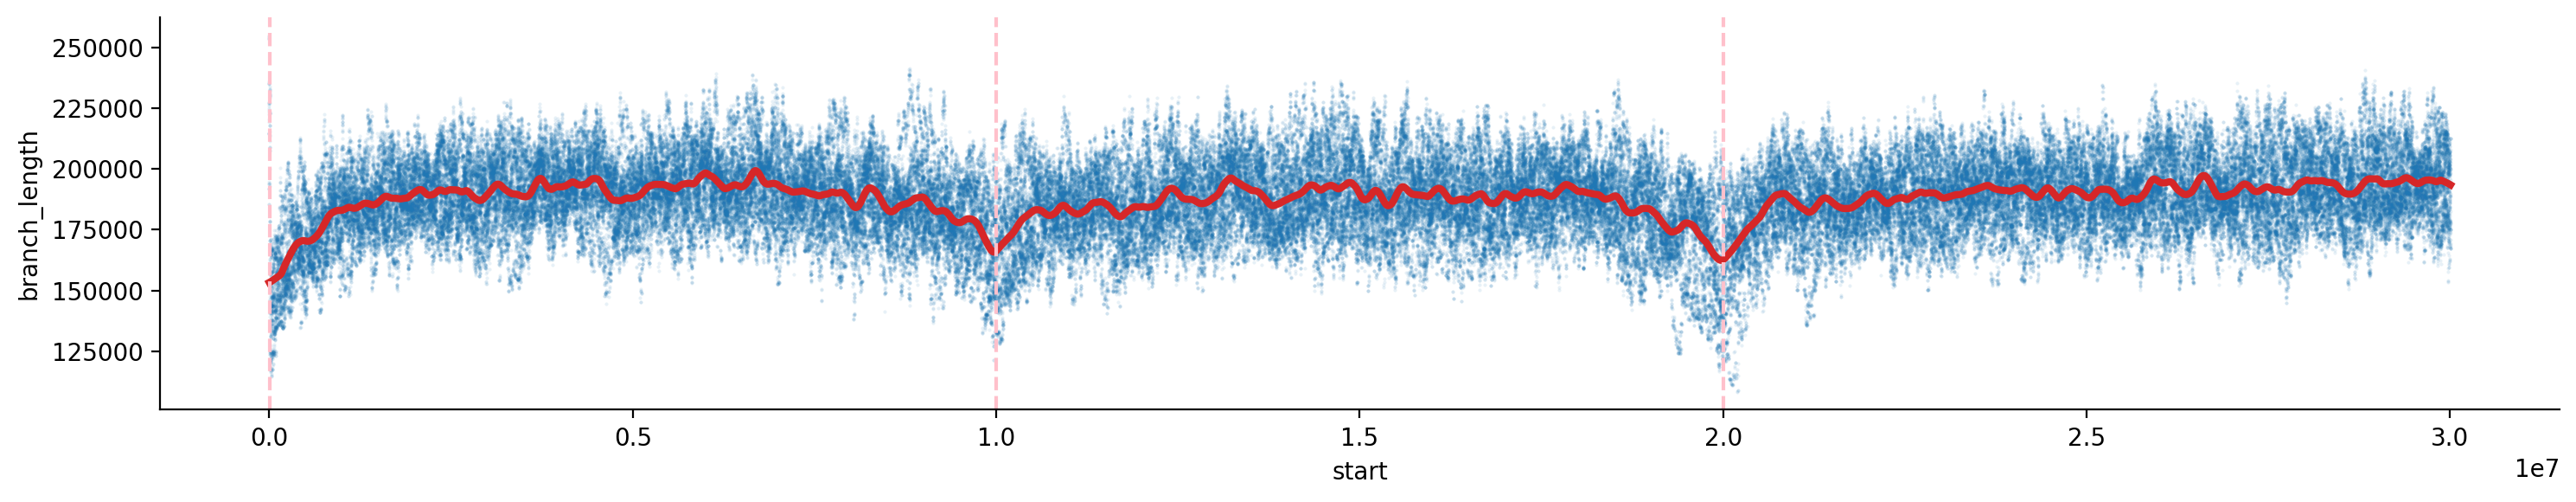

In [13]:
g = sns.FacetGrid(tree_stats_df.groupby('pos').mean(), height=3, aspect=5)
g.map(plt.scatter, "start", 'branch_length', s=1, color='C0', marker='.', alpha=0.1)
g.map(add_lowess, "start", 'branch_length', frac=0.01, is_sorted=False, color='C3', linewidth=3)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

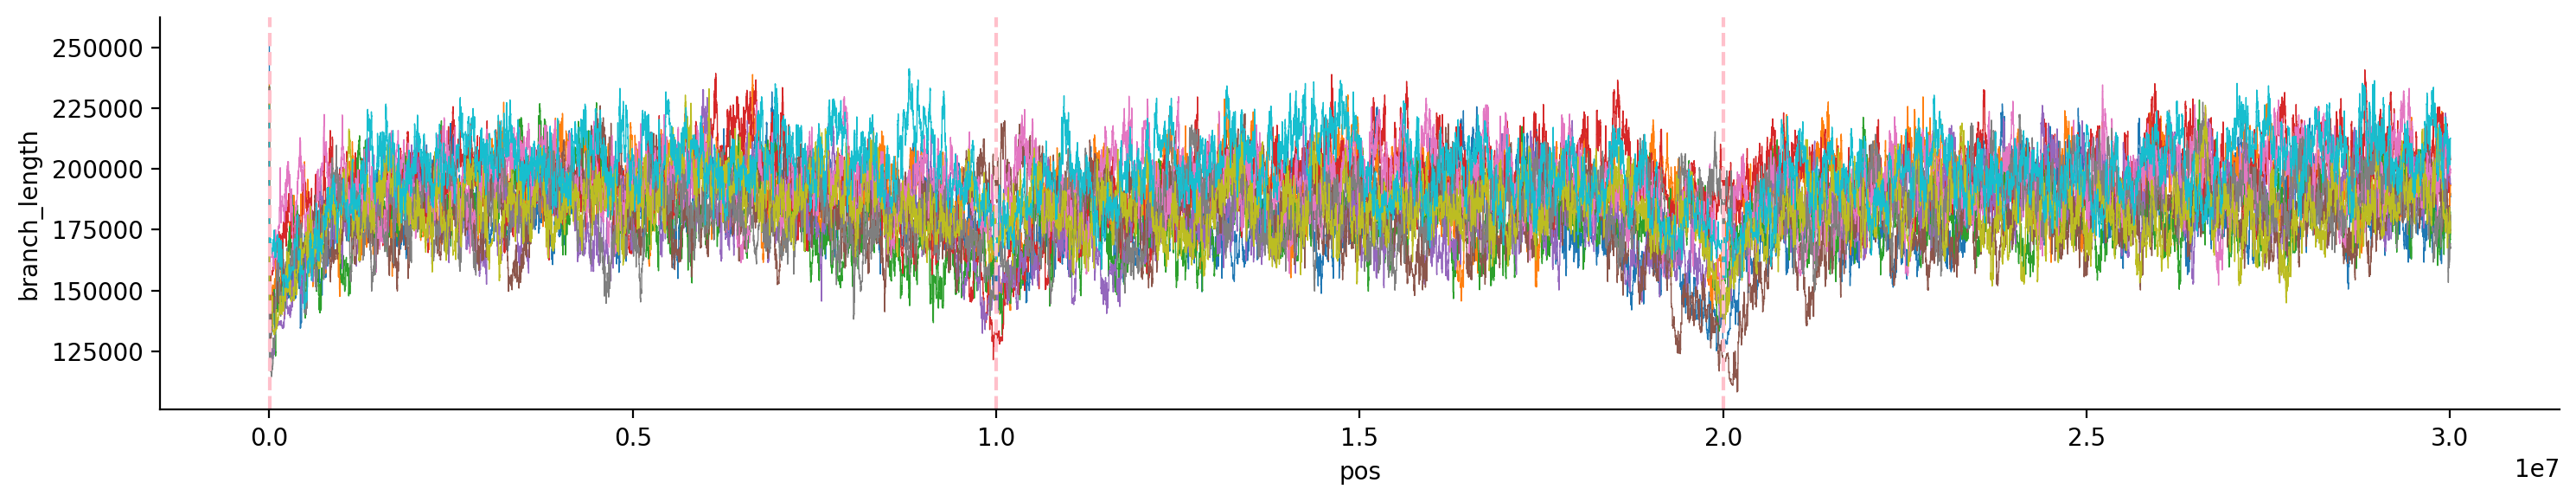

In [14]:
g = sns.FacetGrid(stairs(tree_stats_df), hue="replicate", height=3, aspect=5)
g.map(plt.plot, "pos", 'branch_length', linewidth=0.5)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

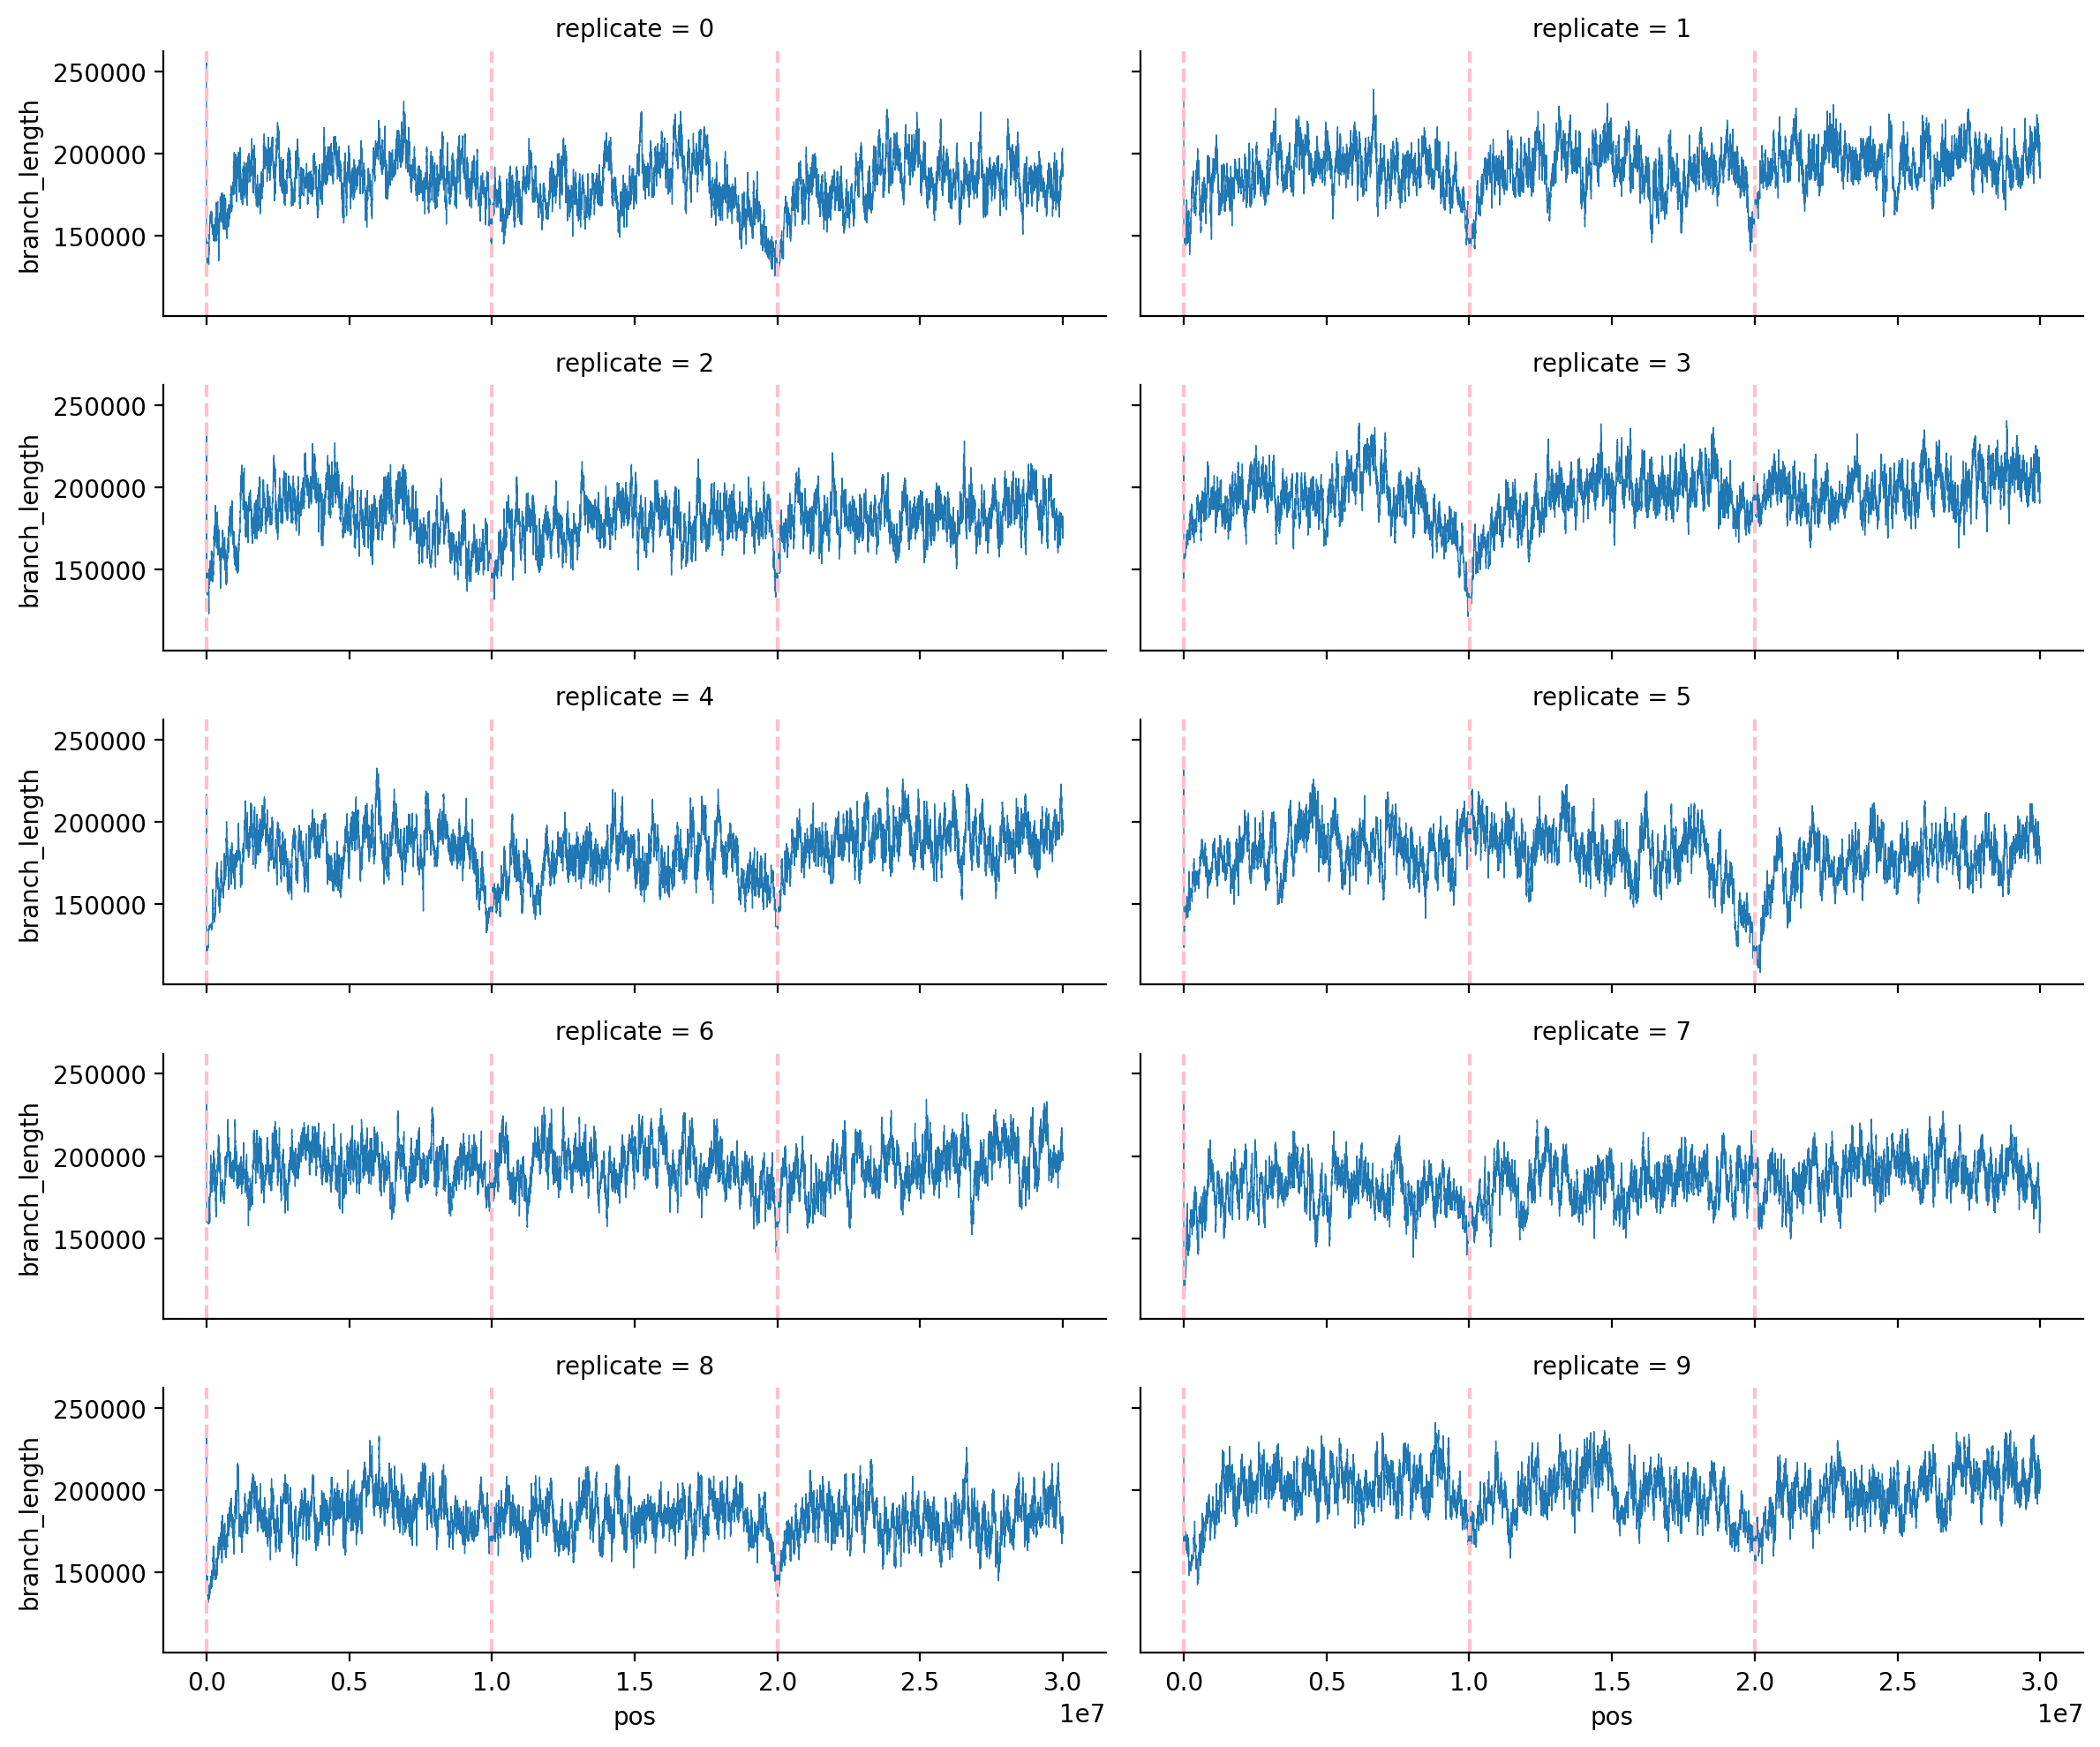

In [15]:
g = sns.FacetGrid(stairs(tree_stats_df), col="replicate", height=2, aspect=3, col_wrap=2)
g.map(plt.plot, "pos", 'branch_length', linewidth=0.5)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

# Window-based stats

Make a True/False mask of whether a window is close to an amplicon:

In [25]:
flank = 200_000
amplicon_neighborhood_mask = (
    (window_stats_df.pos > amplicon_average_positions[0]-flank) & (window_stats_df.pos < amplicon_average_positions[0]+flank) |
    (window_stats_df.pos > amplicon_average_positions[1]-flank) & (window_stats_df.pos < amplicon_average_positions[1]+flank) |
    (window_stats_df.pos > amplicon_average_positions[2]-flank) & (window_stats_df.pos < amplicon_average_positions[2]+flank)
)

## Diversity

(avg pair-wise branch length distance between sample pairs)

All replicates together:

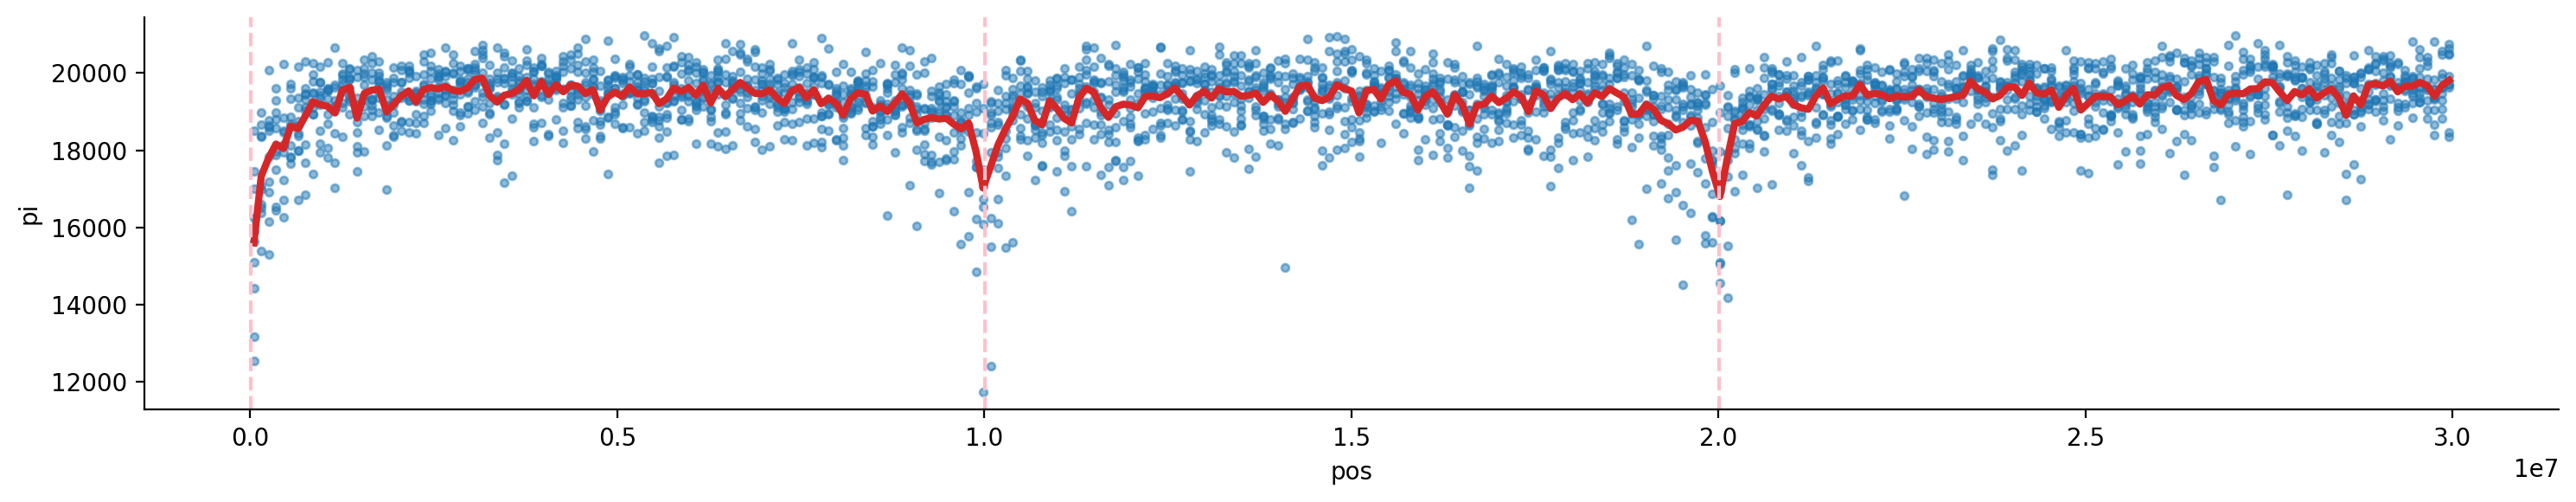

In [41]:
g = sns.FacetGrid(window_stats_df, height=3, aspect=5)
g.map(plt.scatter, "pos", 'pi', s=10, color='C0', alpha=0.5)
g.map(add_lowess, "pos", 'pi', frac=0.01, is_sorted=False, color='C3', linewidth=3)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

Mean over replicates:

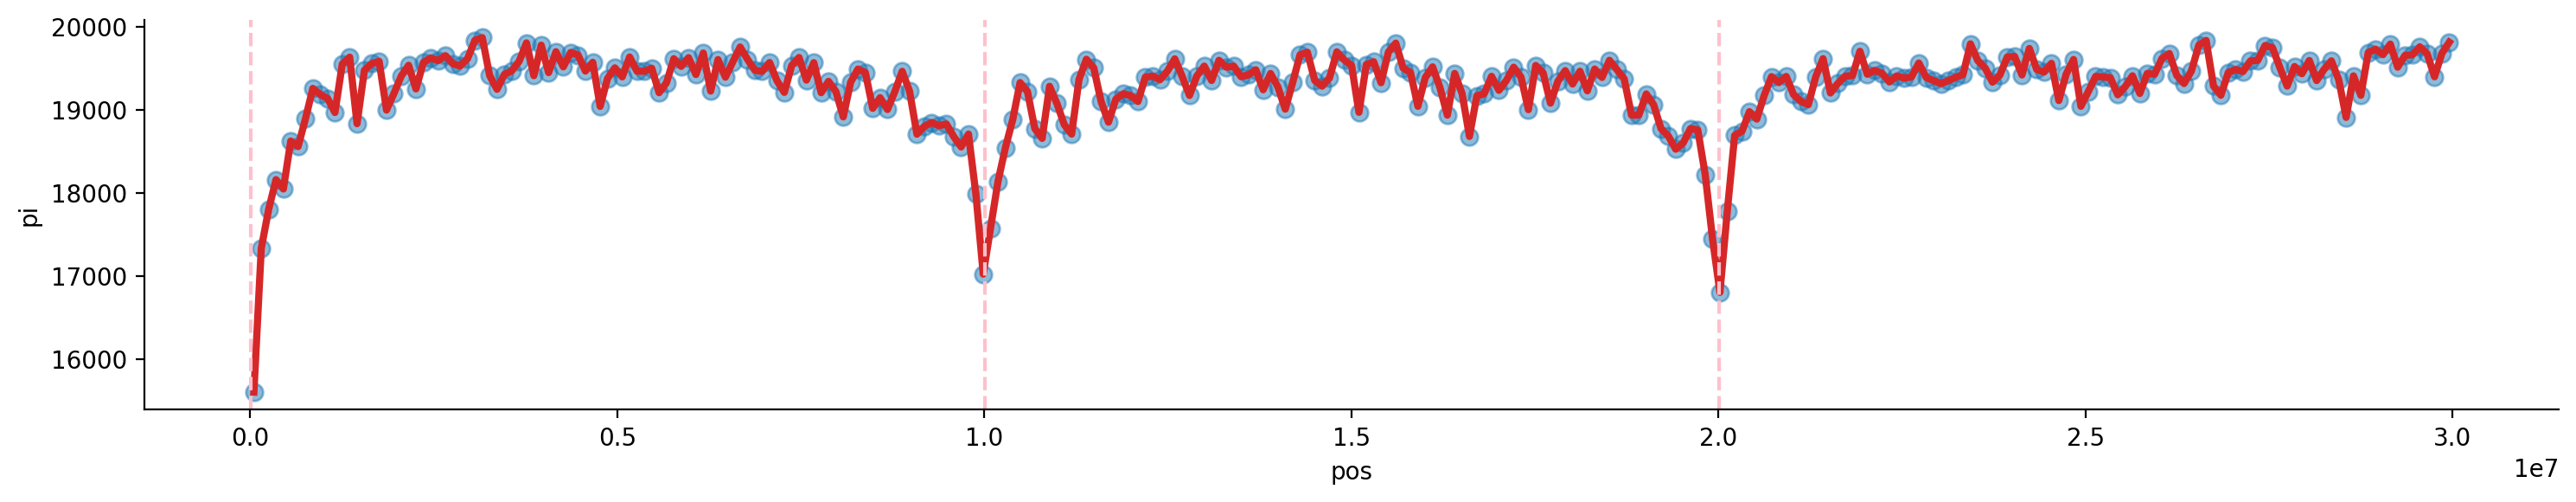

In [43]:
g = sns.FacetGrid(window_stats_df.groupby('pos').mean().reset_index(), height=3, aspect=5)
g.map(plt.scatter, "pos", 'pi', s=50, color='C0', alpha=0.5)
g.map(add_lowess, "pos", 'pi', frac=0.01, is_sorted=False, color='C3', linewidth=3)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

Showing the amplicon neighborhood windows:

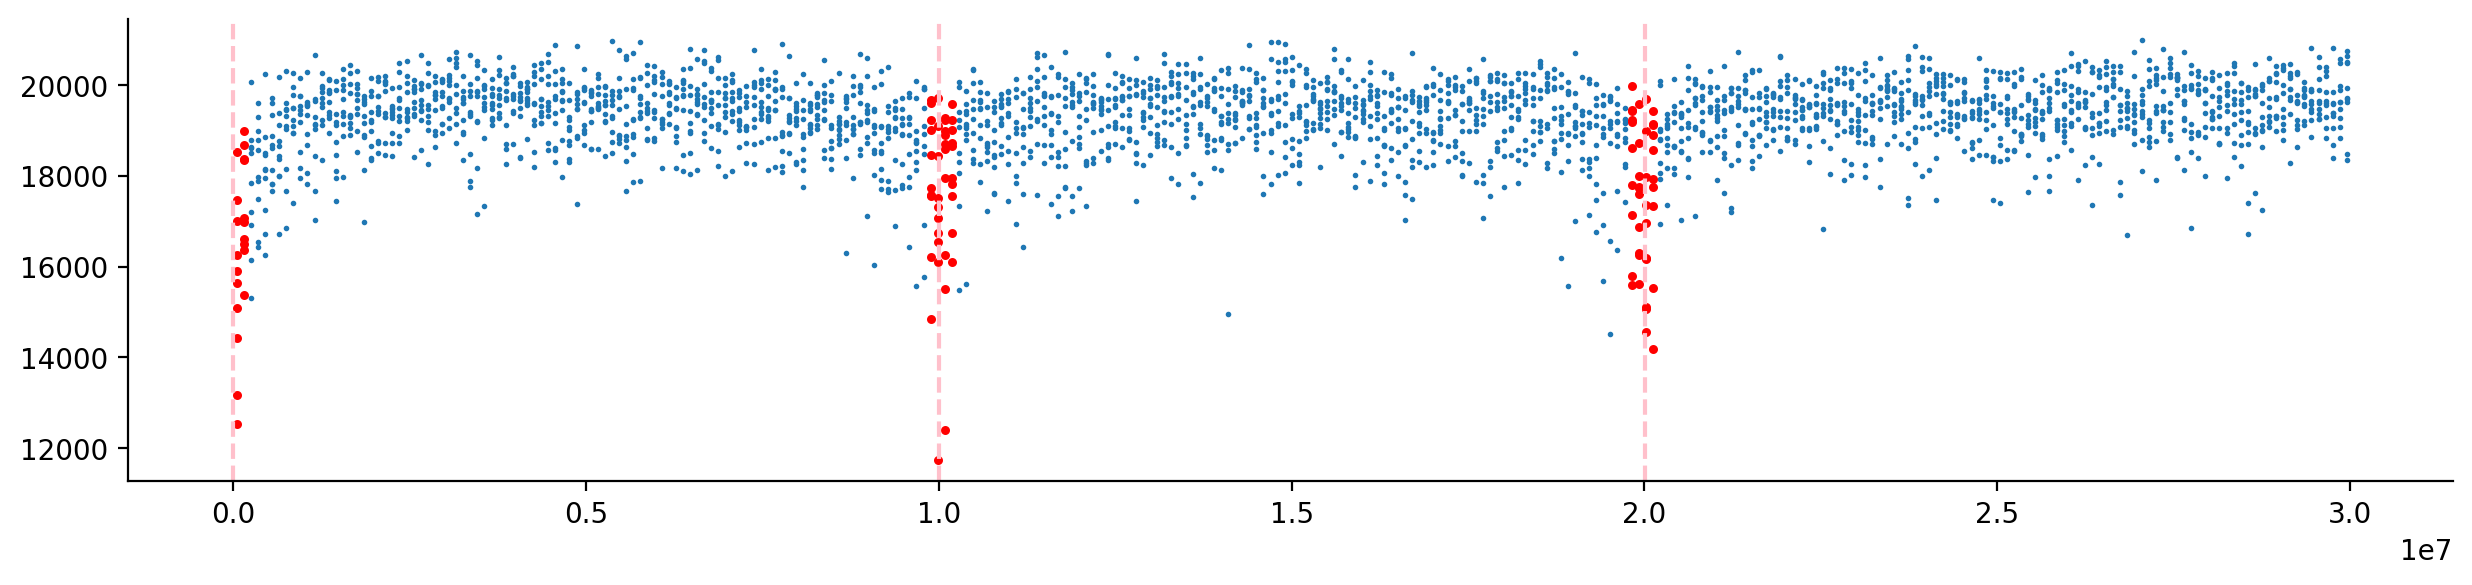

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(15, 3))
ax.scatter(window_stats_df.pos, window_stats_df.pi, s=1)
for vline in amplicon_average_positions:
    ax.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
subset_df = window_stats_df.loc[amplicon_neighborhood_mask]
ax.scatter(subset_df.pos, subset_df.pi, s=5, color='red')
sns.despine()

Mean inside/outside amplicons:

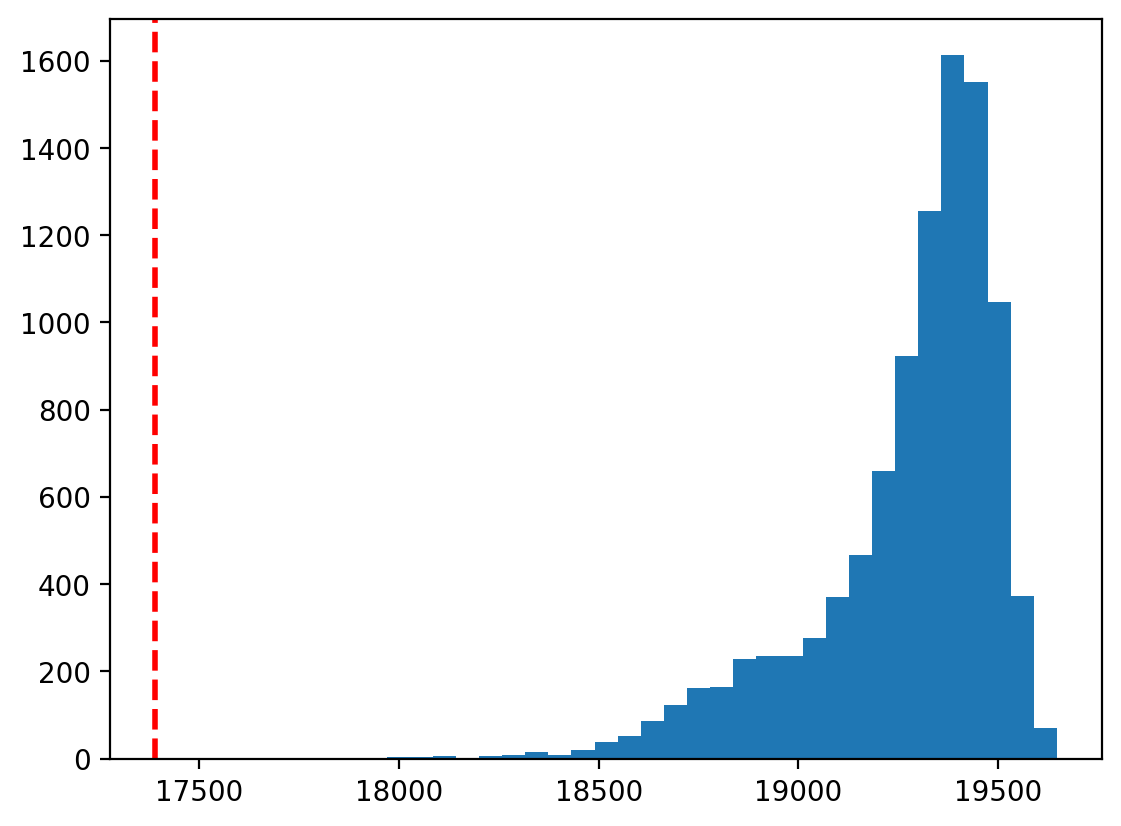

In [103]:
import random
stat = 'pi'
observed_value = window_stats_df.loc[amplicon_neighborhood_mask, stat].mean()
bootstraps = []
for _ in range(10000):
    a, b, c = random.randrange(int(3e7)), random.randrange(int(3e7)), random.randrange(int(3e7))
    random_neighborhood_mask = (
        (window_stats_df.pos > a-flank) & (window_stats_df.pos < a+flank) |
        (window_stats_df.pos > b-flank) & (window_stats_df.pos < b+flank) |
        (window_stats_df.pos > c-flank) & (window_stats_df.pos < c+flank)
    )
    bootstraps.append(window_stats_df.loc[random_neighborhood_mask, stat].mean())
plt.hist(bootstraps, bins=30) ;
plt.axvline(x = observed_value, color='red', linestyle='--', lw = 2) ;

In [106]:
boots = np.array(bootstraps)
pvalue = sum(boots <= observed_value) / boots.size
assert pvalue != 1
if pvalue == 0:
    print(f"Permutation test p-value: {pvalue}")
else:
    print(f"Permutation test p-value < {1/boots.size}")

Permutation test p-value: 0.0


## Tajima's D

(measured in terms of branch length, not mutations)

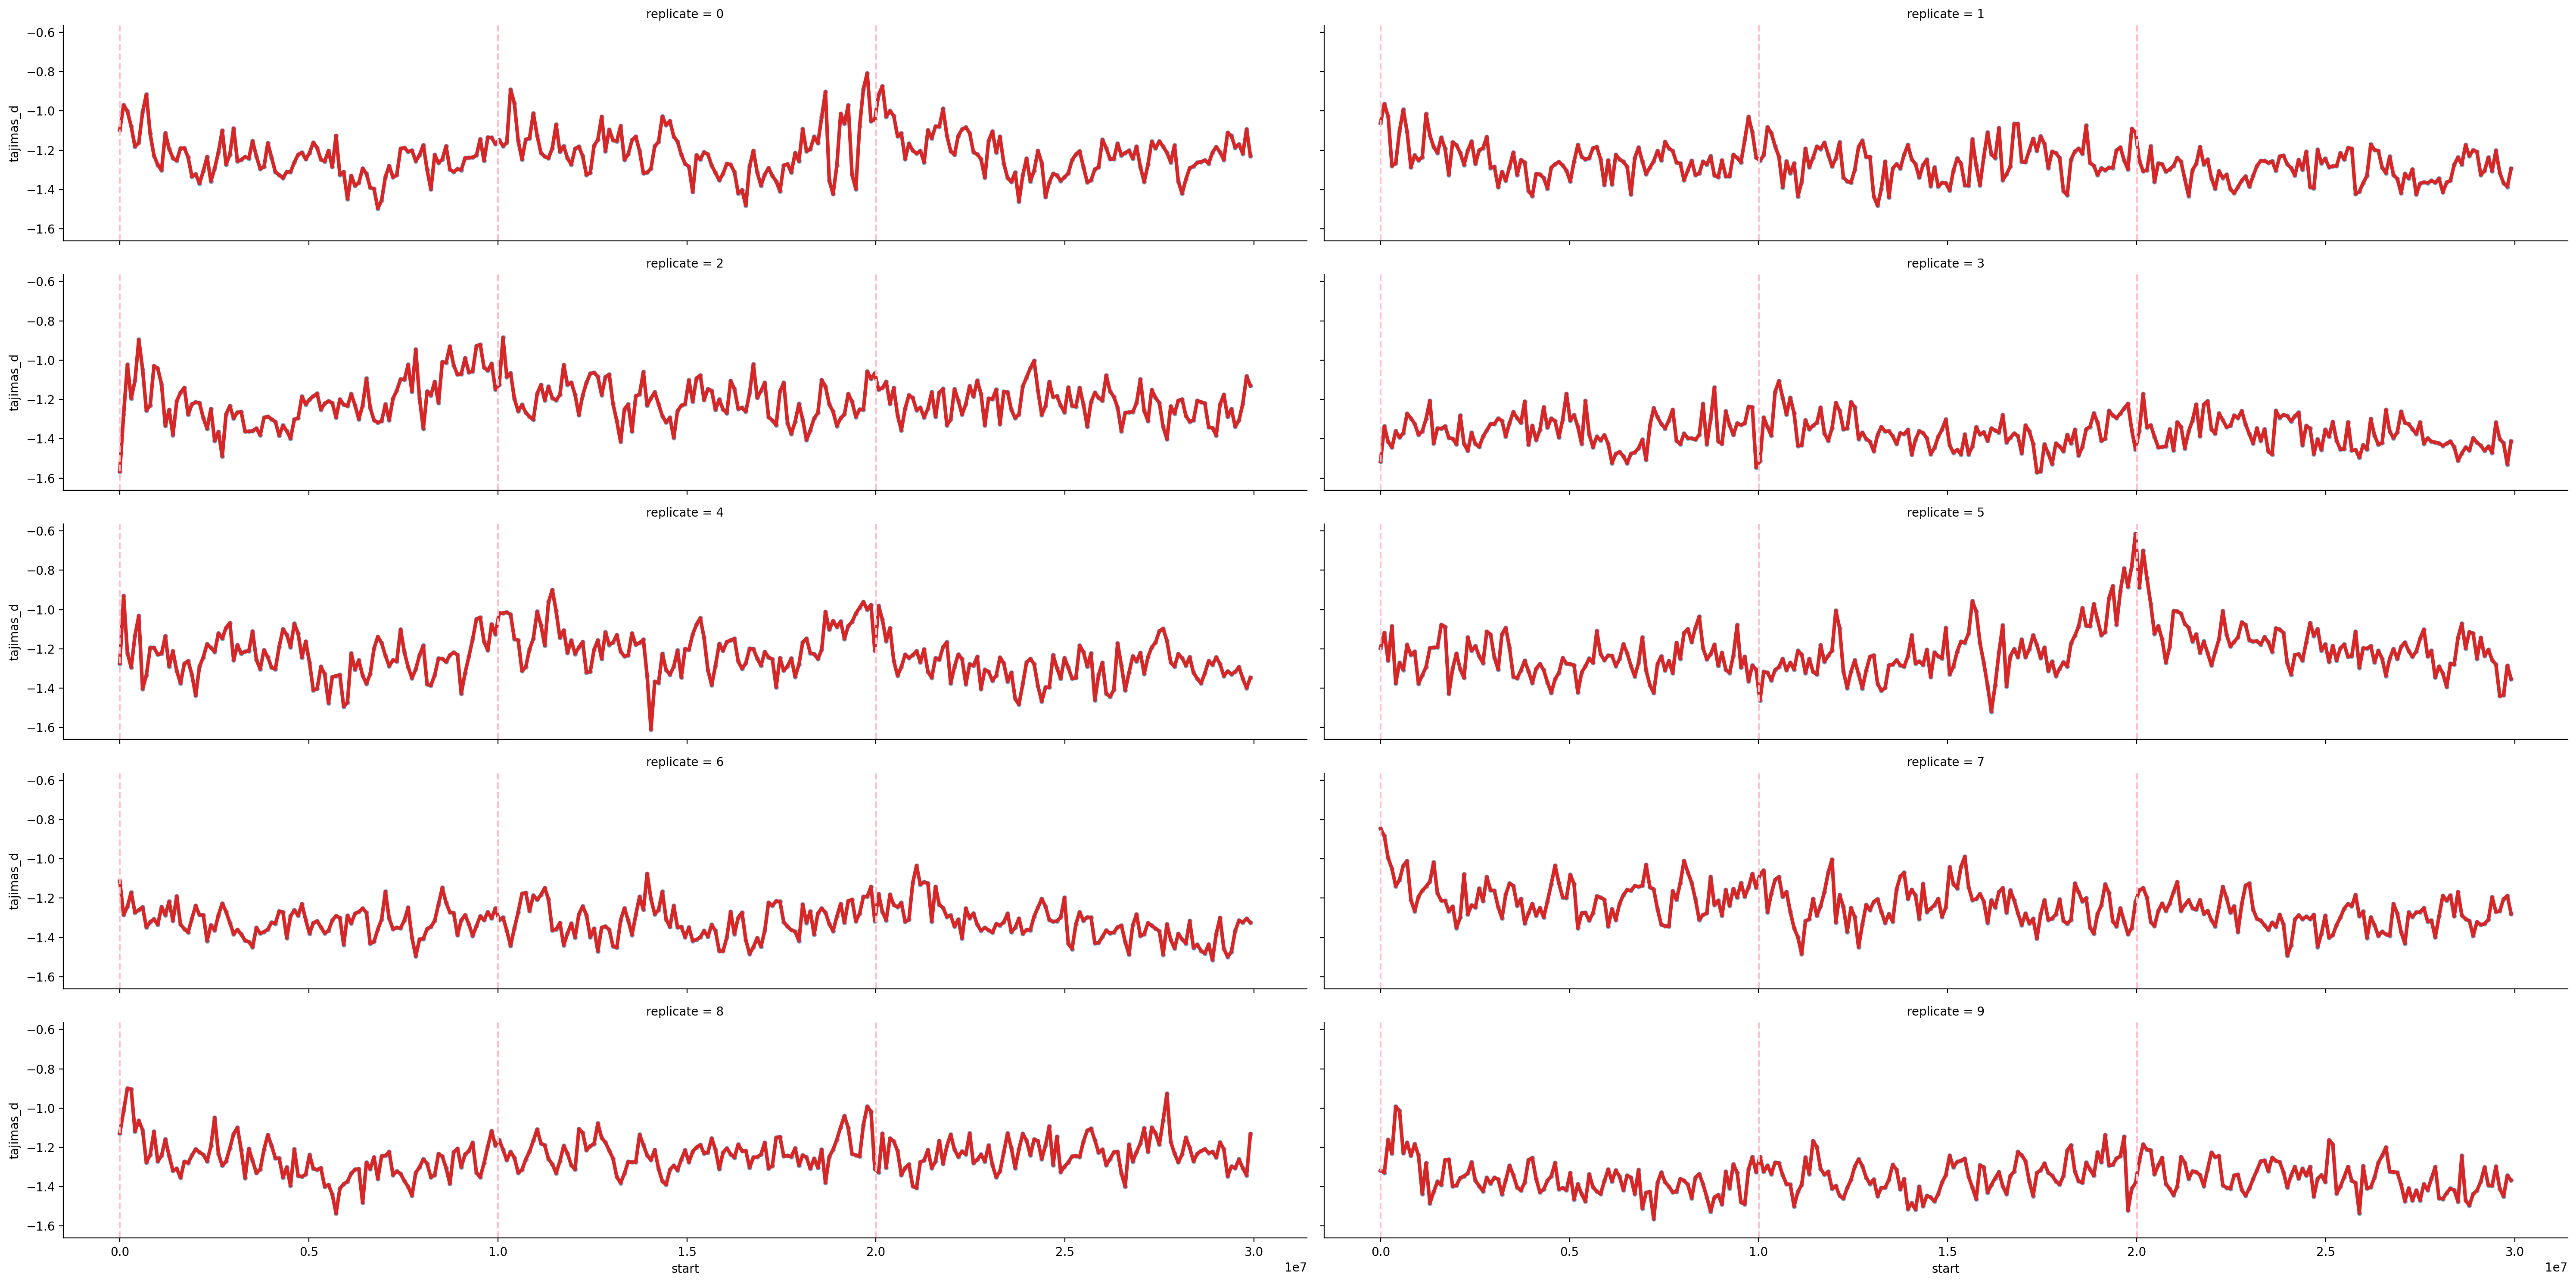

In [37]:
g = sns.FacetGrid(window_stats_df, col="replicate", height=3, aspect=5, col_wrap=2)
g.map(plt.scatter, "start", 'tajimas_d', s=10, color='C0', alpha=0.5)
g.map(add_lowess, "start", 'tajimas_d', frac=0.01, is_sorted=False, color='C3', linewidth=3)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

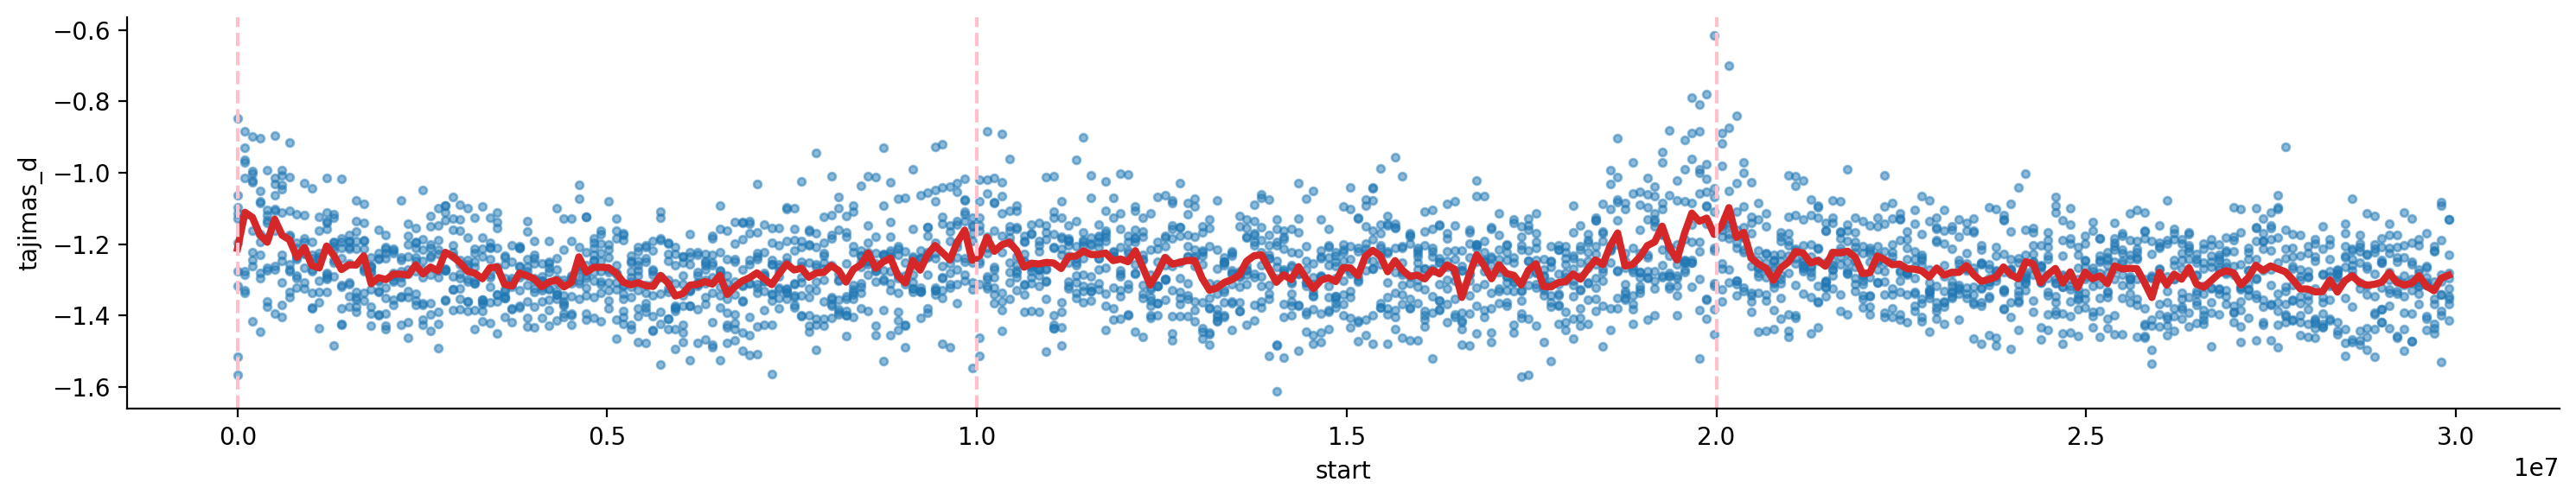

In [38]:
g = sns.FacetGrid(window_stats_df, height=3, aspect=5)
g.map(plt.scatter, "start", 'tajimas_d', s=10, color='C0', alpha=0.5)
g.map(add_lowess, "start", 'tajimas_d', frac=0.01, is_sorted=False, color='C3', linewidth=3)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

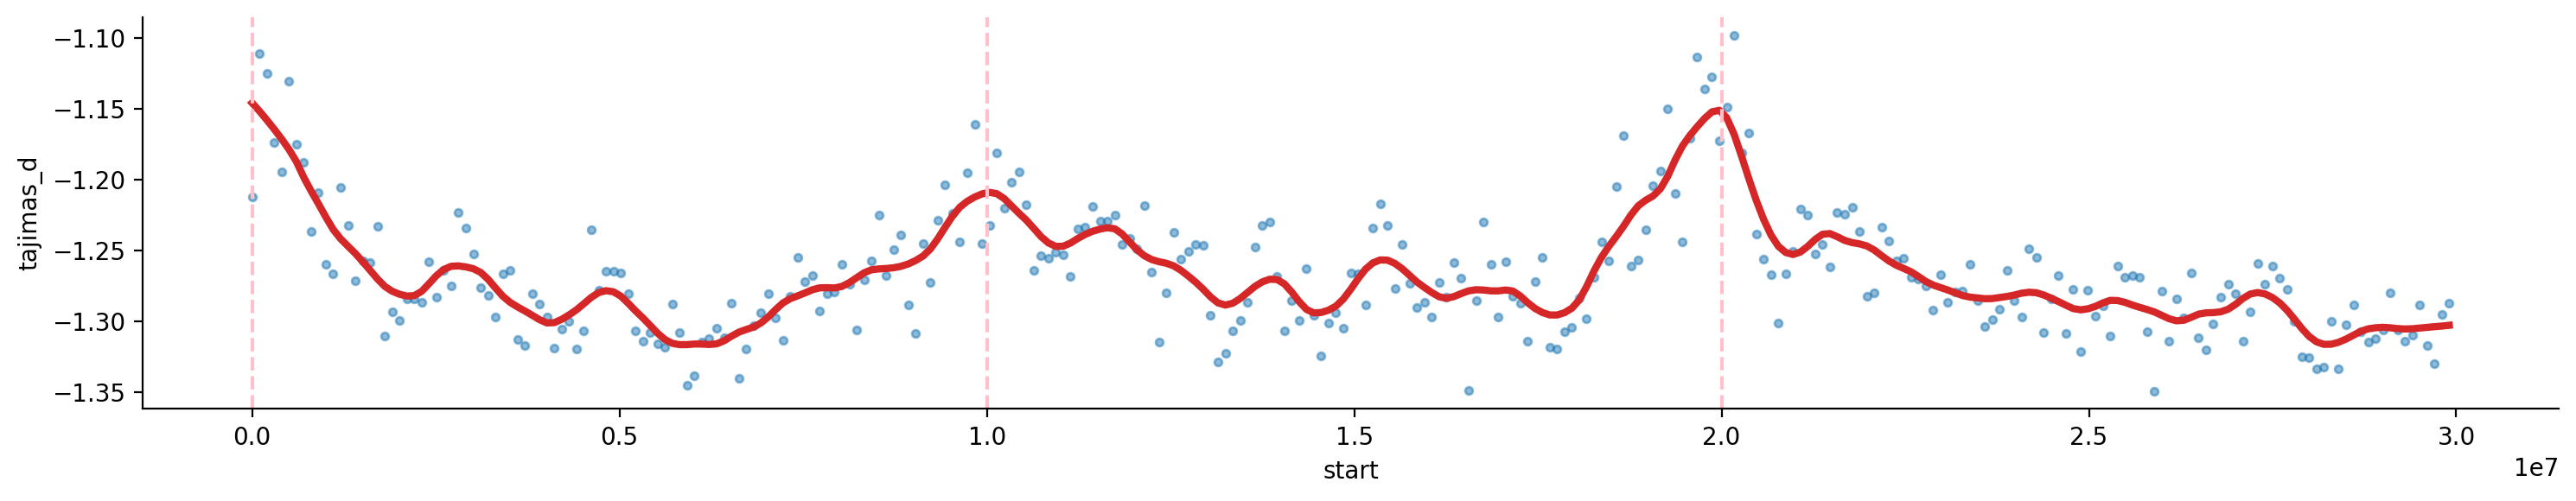

In [39]:
g = sns.FacetGrid(window_stats_df.groupby('pos').mean(), height=3, aspect=5)
g.map(plt.scatter, "pos", 'tajimas_d', s=10, color='C0', alpha=0.5)
g.map(add_lowess, "pos", 'tajimas_d', frac=0.05, is_sorted=False, color='C3', linewidth=3)
for axs in g.axes.flat:
    for vline in amplicon_average_positions:
        axs.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
g.tight_layout() ;

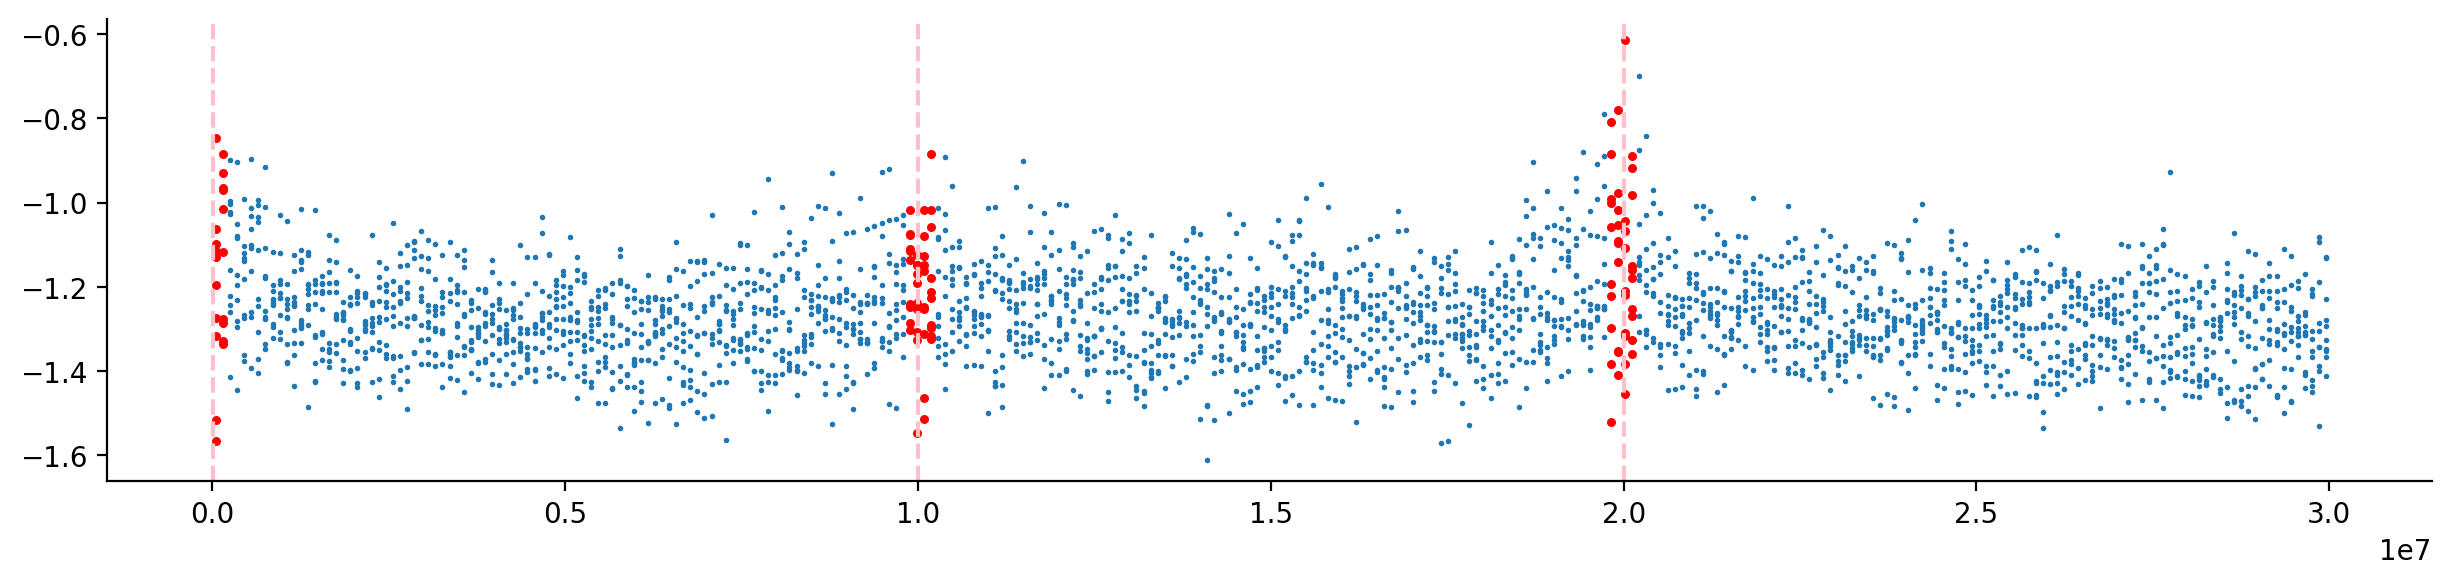

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(15, 3))
ax.scatter(window_stats_df.pos, window_stats_df.tajimas_d, s=1)
for vline in amplicon_average_positions:
    ax.axvline(x = vline, color='pink', linestyle='--', lw = 1.5)
subset_df = window_stats_df.loc[amplicon_neighborhood_mask]
ax.scatter(subset_df.pos, subset_df.tajimas_d, s=5, color='red')
sns.despine()

In [58]:
observed_value

(17389.56611911665, 19335.194407091236)

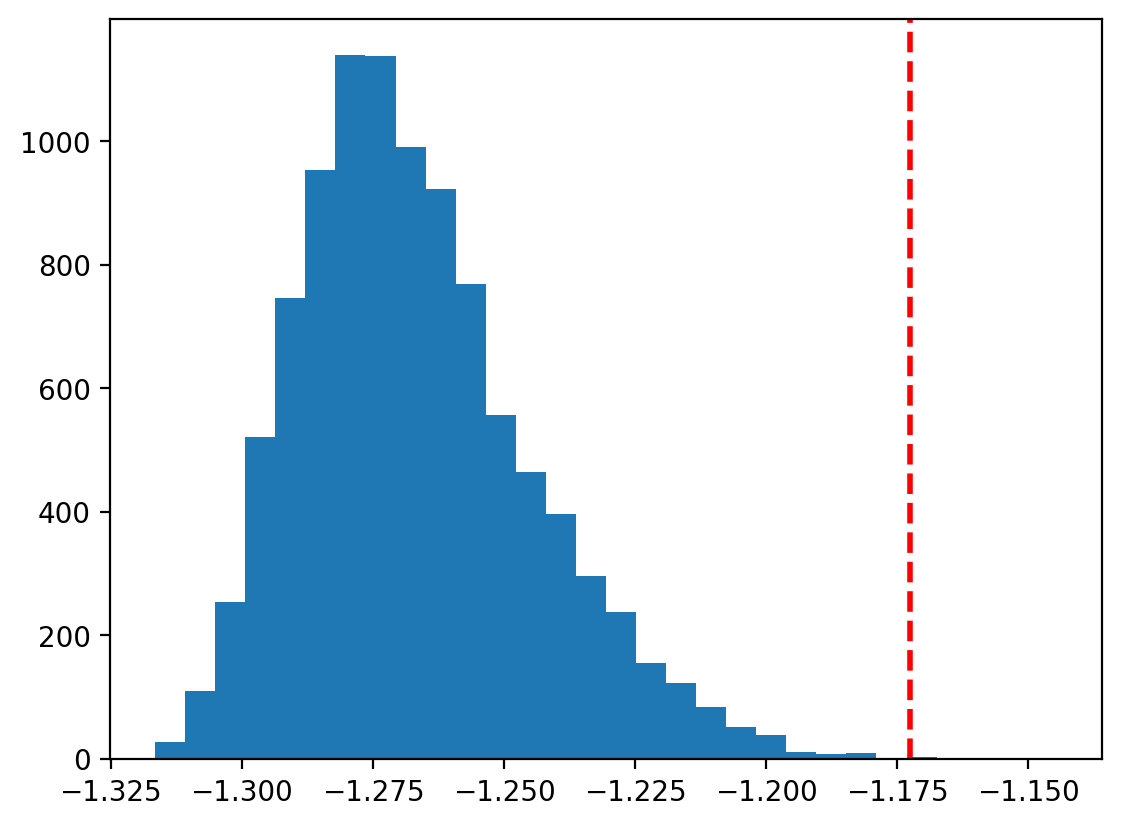

In [107]:
import random
stat = 'tajimas_d'
observed_value = window_stats_df.loc[amplicon_neighborhood_mask, stat].mean()
bootstraps = []
for _ in range(10000):
    a, b, c = random.randrange(int(3e7)), random.randrange(int(3e7)), random.randrange(int(3e7))
    random_neighborhood_mask = (
        (window_stats_df.pos > a-flank) & (window_stats_df.pos < a+flank) |
        (window_stats_df.pos > b-flank) & (window_stats_df.pos < b+flank) |
        (window_stats_df.pos > c-flank) & (window_stats_df.pos < c+flank)
    )
    bootstraps.append(window_stats_df.loc[random_neighborhood_mask, stat].mean())
plt.hist(bootstraps, bins=30) ;
plt.axvline(x = observed_value, color='red', linestyle='--', lw = 2) ;

**p-value:**

In [108]:
boots = np.array(bootstraps)
pvalue = sum(boots >= observed_value) / boots.size
assert pvalue != 1
if pvalue == 0:
    print(f"Permutation test p-value: {pvalue}")
else:
    print(f"Permutation test p-value < {1/boots.size}")

Permutation test p-value < 0.0001
